In [1]:
!pip install tensorflow tensorflow_hub pillow matplotlib -q

In [2]:
from google.colab import files

uploaded = files.upload()

Saving content.jpg to content.jpg
Saving style.jpg to style.jpg


Loading Neural Style Transfer model...
Applying style...


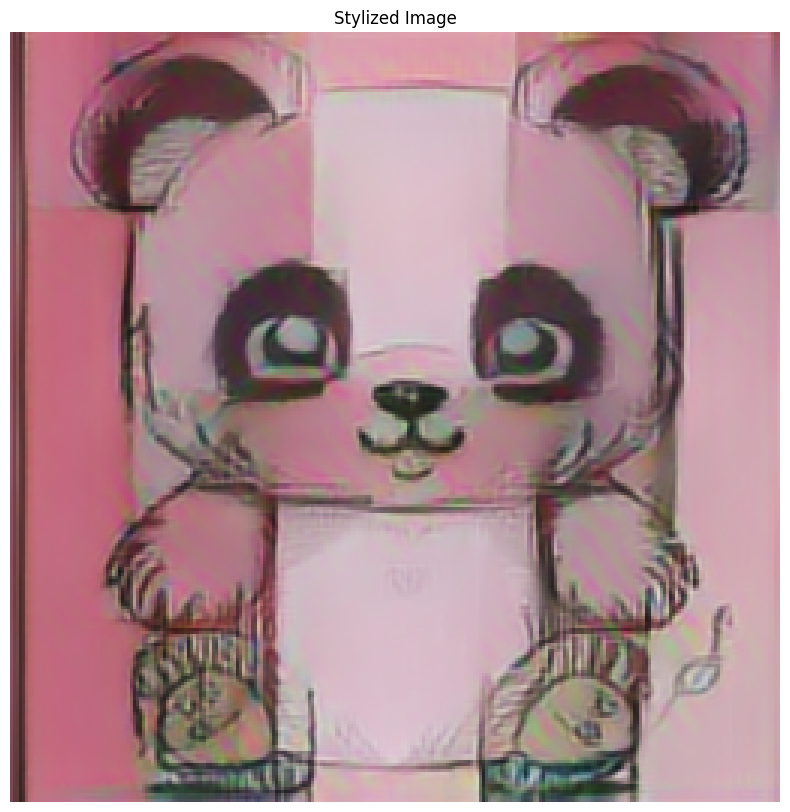

In [3]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Function to load image
def load_image(path):
    img = Image.open(path)
    img = img.resize((256, 256))
    img = np.array(img)/255.0
    img = img.astype(np.float32)
    img = img[np.newaxis, :]
    return img

# Load content and style images
content_image = load_image("content.jpg")
style_image = load_image("style.jpg")

print("Loading Neural Style Transfer model...")

# Load AI model
model = hub.load(
    'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'
)

print("Applying style...")

# Apply style transfer
stylized_image = model(
    tf.constant(content_image),
    tf.constant(style_image)
)[0]

# Display output image
plt.figure(figsize=(10,10))
plt.imshow(stylized_image[0])
plt.axis('off')
plt.title("Stylized Image")
plt.show()